# Jorge Carbajal SID: 862552655

# Data Challenge

## Organization

- **Shared setup**: imports, seeds, and paths (create `data` folder for the data and download from: https://data.transportation.gov/stories/s/Form-57-Data-Downloads/i5dw-jvsi/).
- **Data loading and cleaning**: Data transforming helper functions and the implementation of that transformation. I also included a short summary of the class balance.
- **Classification**: compare Decision Tree and TabNet on `injury_present`.
- **Clustering**: compare K-medoids/PAM and HDBSCAN on a shared sampled distance matrix.
- **Results**: show compact tables and plots for the final report.

## Shared Setup

### Imports

In [101]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kmedoids
import torch
from pytorch_tabnet.tab_model import TabNetClassifier

from IPython.display import display
from sklearn.cluster import HDBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

### Reproducibility

In [102]:
# decouple reproducability
SEED = 15
CLUSTER_SEED = 42


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(SEED)

### Paths

In [103]:
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
# FIGURE_DIR = ROOT / "figures"
# FIGURE_DIR.mkdir(exist_ok=True)

RAW_DATA_PATTERN = "Highway-Rail_Grade_Crossing_Incident_Data_(Form_57)_*.csv"

matches = list(DATA_DIR.glob(RAW_DATA_PATTERN))

if not matches:
    raise FileNotFoundError(f"Expected raw data matching {DATA_DIR / RAW_DATA_PATTERN}")

RAW_DATA_PATH = max(matches, key=lambda p: p.stat().st_mtime)

## Data Loading and Cleaning

### Helper Functions

In [104]:
KEPT_FEATURES = [
    "Crossing Illuminated",
    "Crossing Users Injured",
    "Crossing Users Killed",
    "Crossing Warning Expanded 1",
    "Crossing Warning Expanded 2",
    "Crossing Warning Expanded 3",
    "Crossing Warning Expanded 4",
    "Crossing Warning Expanded 5",
    "Crossing Warning Expanded 6",
    "Crossing Warning Expanded 7",
    "Crossing Warning Expanded 8",
    "Crossing Warning Expanded 9",
    "Crossing Warning Expanded 10",
    "Crossing Warning Expanded 11",
    "Crossing Warning Expanded 12",
    "Date",
    "Driver In Vehicle",
    "Driver Passed Vehicle",
    "Employees Injured",
    "Employees Killed",
    "Equipment Involved",
    "Equipment Struck",
    "Equipment Type",
    "Estimated Vehicle Speed",
    "Highway User",
    "Highway User Action",
    "Highway User Position",
    "Hour",
    "Month",
    "Number of Cars",
    "Number Vehicle Occupants",
    "Passengers Injured",
    "Passengers Killed",
    "Report Key",
    "Temperature",
    "Time",
    "Total Injured Form 55A",
    "Total Injured Form 57",
    "Total Killed Form 55A",
    "Total Killed Form 57",
    "Track Type",
    "Train Speed",
    "Vehicle Damage Cost",
    "View Obstruction",
    "Visibility",
    "Warning Connected To Signal",
    "Weather Condition",
]

def transform_warning_devices(df) -> pd.DataFrame:
    """
    Transform the warning device columns into binary categories. Remove the columns and return the DataFrame.
    """

    df = df.copy()
    warning_columns = [f"Crossing Warning Expanded {i}" for i in range(1, 13)]
    normalized = df[warning_columns].apply(lambda col: col.astype("string").str.strip().str.lower())

    device_mapping = {
        "has_gate": ["gates", "gate"],
        "has_cantilever_fls": ["cantilever fls"],
        "has_standard_fls": ["standard fls"],
        "has_wig_wags": ["wig wags", "wig wag"],
        "has_highway_traffic_signals": ["highway traffic signals", "hwy. traffic signals"],
        "has_audible": ["audible"],
        "has_crossbucks": ["crossbucks", "crossbuck"],
        "has_stop_signs": ["stop signs", "stop sign"],
        "has_watchman": ["watchman"],
        "has_flagged_by_crew": ["flagged by crew"],
        "has_other_warning": ["other"],
        "has_no_warning_device": ["none"],
    }

    for new_column, possible_values in device_mapping.items():
        df[new_column] = normalized.isin(possible_values).any(axis=1).astype(int)

    return df.drop(columns=warning_columns)

def transform_time_variables(df) -> pd.DataFrame:
    """
    Create year, season, and time_of_day columns. Remove the Month, Hour, and Time columns.
    """

    df = df.copy()
    parsed_date = pd.to_datetime(df["Date"], errors="coerce")
    df["year"] = parsed_date.dt.year.astype("Int64")

    season_mapping = {
        12: "Winter", 1: "Winter", 2: "Winter",
        3: "Spring", 4: "Spring", 5: "Spring",
        6: "Summer", 7: "Summer", 8: "Summer",
        9: "Fall", 10: "Fall", 11: "Fall",
    }
    df["season"] = parsed_date.dt.month.map(season_mapping)

    parsed_time = pd.to_datetime(df["Time"], format="%I:%M %p", errors="coerce")
    hour = parsed_time.dt.hour
    df["time_of_day"] = pd.cut(
        hour,
        bins=[-1, 5, 11, 17, 23],
        labels=["Night", "Morning", "Afternoon", "Evening"],
    )

    return df.drop(columns=["Month", "Hour", "Time"])

def clean_numeric_features(df) -> pd.DataFrame:
    """
    Clean up Vehicle Damage numbering, and for all numerical features convert out of range values into NaN
    """

    df = df.copy()
    damage_cleaned = (
        df["Vehicle Damage Cost"].astype("string")
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
    )
    df["Vehicle Damage Cost"] = pd.to_numeric(damage_cleaned, errors="coerce")

    numeric_features = [
        "Train Speed",
        "Estimated Vehicle Speed",
        "Number Vehicle Occupants",
        "Number of Cars",
        "Temperature",
    ]
    for feature in numeric_features:
        df[feature] = pd.to_numeric(df[feature], errors="coerce")

    df.loc[df["Train Speed"] > 110, "Train Speed"] = pd.NA
    df.loc[df["Estimated Vehicle Speed"] > 120, "Estimated Vehicle Speed"] = pd.NA
    df.loc[df["Number of Cars"] > 300, "Number of Cars"] = pd.NA
    df.loc[(df["Temperature"] < -80) | (df["Temperature"] > 130), "Temperature"] = pd.NA

    return df

def build_v1_dataset(raw_df) -> pd.DataFrame:
    """
    Ensure we have all the KEPT_FEATURES, Drop duplicates, create outcome columns, apply all the above functions
    """

    missing_features = [feature for feature in KEPT_FEATURES if feature not in raw_df.columns]
    if missing_features:
        raise ValueError(f"Missing expected raw columns: {missing_features}")

    df = raw_df[KEPT_FEATURES].copy()
    df = df.drop_duplicates(subset="Report Key", keep="first").copy()

    killed_55a = pd.to_numeric(df["Total Killed Form 55A"], errors="coerce")
    injured_55a = pd.to_numeric(df["Total Injured Form 55A"], errors="coerce")
    df["fatality_present"] = (killed_55a > 0).astype(int)
    df["injury_present"] = (injured_55a > 0).astype(int)

    df = transform_warning_devices(df)
    df = transform_time_variables(df)
    df = clean_numeric_features(df)

    return df

### Load & Build Dataset

In [105]:
raw_df = pd.read_csv(RAW_DATA_PATH, low_memory=False)
v1_df = build_v1_dataset(raw_df)

## Classification

### Helper Functions

In [106]:
TARGET = "injury_present"
TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20

EXCLUDED_COLUMNS = [
    "injury_present",
    "Report Key",
    "Date",
    "year",
    "Crossing Users Injured",
    "Crossing Users Killed",
    "Employees Injured",
    "Employees Killed",
    "Passengers Injured",
    "Passengers Killed",
    "Total Injured Form 55A",
    "Total Injured Form 57",
    "Total Killed Form 55A",
    "Total Killed Form 57",
    "fatality_present",
    "Vehicle Damage Cost",
]

def get_excluded_columns(df) -> list:
    """
    Builds and returns a list of excluded columns and columns that are constant (constant columns provide no value).
    """

    excluded = [column for column in EXCLUDED_COLUMNS if column in df.columns]
    excluded_set = set(excluded)
    constant_columns = [
        column for column in df.columns
        if column != TARGET
        and column not in excluded_set
        and df[column].nunique(dropna=True) <= 1
    ]
    return excluded + constant_columns

def get_predictor_columns(df) -> list:
    """
    Return a list of the final columns we will use to model. Ensure no data leakage.
    """

    excluded = set(get_excluded_columns(df))
    predictors = [column for column in df.columns if column not in excluded]

    risky_words = ["injur", "kill", "fatal", "damage", "cost", "report", "key", "date"]
    risky_predictors = [
        column for column in predictors
        if any(word in column.lower() for word in risky_words)
    ]
    if risky_predictors:
        raise ValueError(f"Possible leakage predictors found: {risky_predictors}")

    return predictors

def get_feature_groups(df, predictors) -> dict:
    """
    Sort and return the predictor columns into three groups so they can later be further cleaned.
    """

    groups = {"numeric": [], "categorical": [], "binary": []}
    for column in predictors:
        values = set(df[column].dropna().unique().tolist())
        if values and values.issubset({0, 1}):
            groups["binary"].append(column)
        elif pd.api.types.is_numeric_dtype(df[column]):
            groups["numeric"].append(column)
        else:
            groups["categorical"].append(column)
    return groups

def make_splits(X, y):
    """
    Splits the data into and 80/20 model/test split. That 80 model split is then further split into another 80/20 train/val split. The validation split is meant for adjusting thresholds to produce better performance.
    """

    X_model, X_test, y_model, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=y,
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_model,
        y_model,
        test_size=VALIDATION_SIZE,
        random_state=SEED,
        stratify=y_model,
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

def find_best_f1_threshold(y_true, probabilities) -> pd.Series:
    """
    This function finds returns the values produced by the threshold that produces the best F1 score.
    """

    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    precision = precision[:-1]
    recall = recall[:-1]
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(precision),
        where=(precision + recall) != 0,
    )
    results = pd.DataFrame({
        "threshold": thresholds,
        "f1": f1,
        "precision": precision,
        "recall": recall,
    })
    results["predicted_positive_count"] = [int((probabilities >= t).sum()) for t in thresholds]
    return results.sort_values(["f1", "precision", "threshold"], ascending=[False, False, False]).iloc[0]

def metric_row(model_name, y_true, probabilities, threshold) -> dict:
    """
    Turns predictions into a clean summary of row evaluation metrics.
    """

    predictions = (probabilities >= threshold).astype(int)
    return {
        "model": model_name,
        "threshold": round(float(threshold), 4),
        "AP / PR-AUC": round(average_precision_score(y_true, probabilities), 4),
        "F1": round(f1_score(y_true, predictions, zero_division=0), 4),
        "precision": round(precision_score(y_true, predictions, zero_division=0), 4),
        "recall": round(recall_score(y_true, predictions, zero_division=0), 4),
        # "predicted injury cases": int(predictions.sum()),
        # "actual injury cases": int((y_true == 1).sum()),
        # "rows": len(y_true),
    }

def build_tree_model(
    feature_groups,
    max_depth=8,
    min_samples_leaf=100,
    class_weight=None,
) -> Pipeline:
    """
    Here we build the pipelines for the necessary data transformations. With numerical data we replace missing values with the median of the column. For categorical data we first replace missing values with the most frequent and then convert those columns into binary columns where each category is its own binary column. The binary pipeline replaced missing valuse with most frequent as well. Columns transformer is needed for applying select transformations to select columns.
    """

    numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ])
    binary_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent"))])

    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, feature_groups["numeric"]),
        ("categorical", categorical_pipeline, feature_groups["categorical"]),
        ("binary", binary_pipeline, feature_groups["binary"]),
    ])

    return Pipeline([
        ("preprocessor", preprocessor),
        ("tree", DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            class_weight=class_weight,
            random_state=SEED,
        )),
    ])

### Splits & Feature groups

In [107]:
# list of predictor columns
predictors = get_predictor_columns(v1_df)

# numeric, categorical, binary groups in a dict
feature_groups = get_feature_groups(v1_df, predictors)

# separate into the data we will use for modeling
X = v1_df[predictors].copy()
y = v1_df[TARGET].copy()

# create the (80 = 64/16)/20 splits
X_train, X_val, X_test, y_train, y_val, y_test = make_splits(X, y)

### Decision Tree

#### Implementation

In [108]:
#################################################################
# BELOW IS THE IMPLEMENTATION AND STORAGE OF THE K FOLD RESULTS #
#################################################################

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# define the parameter search space
tree_grid = [
    {"max_depth": 4, "min_samples_leaf": 50, "class_weight": None},
    {"max_depth": 6, "min_samples_leaf": 50, "class_weight": None},
    {"max_depth": 8, "min_samples_leaf": 100, "class_weight": None},
    {"max_depth": 10, "min_samples_leaf": 100, "class_weight": None},
    {"max_depth": 8, "min_samples_leaf": 100, "class_weight": "balanced"},
    {"max_depth": 10, "min_samples_leaf": 200, "class_weight": "balanced"},
]

# a list of dicts that will hold the results for each parameter subset
search_rows = []

# loop through the parameter space
for candidate_id, params in enumerate(tree_grid, start=1):
    fold_rows = []

    # for each 3 fold cross validation split
    for fold, (train_index, fold_index) in enumerate(skf.split(X_train, y_train), start=1):
        # build the model with the parameters from space
        fold_model = build_tree_model(feature_groups, **params)

        # train model
        fold_model.fit(
            X_train.iloc[train_index],
            y_train.iloc[train_index],
        )

        # calculate probablilites and find best threshold
        fold_prob = fold_model.predict_proba(X_train.iloc[fold_index])[:, 1]
        fold_threshold = float(find_best_f1_threshold(y_train.iloc[fold_index], fold_prob)["threshold"])

        # for the fold, calculate the metrics dict and append it
        fold_rows.append(
            metric_row(
                f"candidate {candidate_id} fold {fold}",
                y_train.iloc[fold_index],
                fold_prob,
                fold_threshold,
            )
        )

    # fold_rows is a list of dicts, convert to df
    fold_results = pd.DataFrame(fold_rows)

    # append each parameter space result into a dict
    search_row = {
        **params,
        "mean AP / PR-AUC": fold_results["AP / PR-AUC"].mean(),
        "mean F1": fold_results["F1"].mean(),
        "mean precision": fold_results["precision"].mean(),
        "mean recall": fold_results["recall"].mean(),
    }

    # add it to the global result
    search_rows.append(search_row)

# convert the results to df
tree_search_results = pd.DataFrame(search_rows)

# find the row label with the max "mean AP / PR-AUC" and store
best_tree_index = tree_search_results["mean AP / PR-AUC"].idxmax()
best_tree_params = {
    "max_depth": tree_search_results.loc[best_tree_index, "max_depth"],
    "min_samples_leaf": tree_search_results.loc[best_tree_index, "min_samples_leaf"],
    "class_weight": tree_search_results.loc[best_tree_index, "class_weight"],
}

# sort all the result in a table
tree_table = tree_search_results.sort_values("mean AP / PR-AUC", ascending=False).copy()

# columns for the table
table_numeric_cols = [
    "mean AP / PR-AUC",
    "mean F1",
    "mean precision",
    "mean recall",
]

# formatting
for column in table_numeric_cols:
    tree_table[column] = tree_table[column].map(lambda value: f"{value:.4f}")

##########################################################
# HERE IS THE IMPLEMENTATION FOR THE CLASSIFICATION PLOT #
##########################################################

tree_model = build_tree_model(feature_groups, **best_tree_params)
tree_model.fit(X_train, y_train)

tree_val_prob = tree_model.predict_proba(X_val)[:, 1]
tree_test_prob = tree_model.predict_proba(X_test)[:, 1]
tree_threshold = float(find_best_f1_threshold(y_val, tree_val_prob)["threshold"])

#### Decision Tree Parameter Space Results

In [109]:
# initialize
fig, ax = plt.subplots(figsize=(12, 2.8))
ax.axis("off")

# table for the decision tree parameter space
table = ax.table(
    cellText=tree_table.values,
    colLabels=tree_table.columns,
    cellLoc="center",
    loc="center",
)

# formatting
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.4)

# fig.savefig(FIGURE_DIR / "decision_tree_hyperparameter_search.png", dpi=200, bbox_inches="tight")
plt.close(fig)

### TabNet

#### Helper Function

In [110]:
def prepare_tabnet_data(X_train, X_val, X_test, feature_groups):
    """
    Prepares the train/validate/test data for the TabNet model. The function ultimately returns the processed versions of those splits along with which columns are categorical and the amount of categories per those columns.
    """

    # TabNet requires a fixture feature order. Since tabnet recieves data as arrays, column position needs ordering.
    ordered_features = feature_groups["numeric"] + feature_groups["categorical"] + feature_groups["binary"]
    X_train_p = pd.DataFrame(index=X_train.index)
    X_val_p = pd.DataFrame(index=X_val.index)
    X_test_p = pd.DataFrame(index=X_test.index)

    # For each numeric column, calculate the median from the test set, and fill missing values with median inside train, validation, and test sets.
    for column in feature_groups["numeric"]:
        median_value = pd.to_numeric(X_train[column], errors="coerce").median()
        for source, target in [(X_train, X_train_p), (X_val, X_val_p), (X_test, X_test_p)]:
            target[column] = pd.to_numeric(source[column], errors="coerce").fillna(median_value).astype("float32")

    # Convert text categories into integer codes from the training data. 
    cat_idxs = []
    cat_dims = []
    for column in feature_groups["categorical"]:
        train_values = X_train[column].astype("string").fillna("__MISSING__")
        categories = sorted(train_values.unique().tolist())
        mapping = {category: index for index, category in enumerate(categories)}
        unknown_code = len(categories)
        cat_idxs.append(ordered_features.index(column))
        cat_dims.append(unknown_code + 1)

        for source, target in [(X_train, X_train_p), (X_val, X_val_p), (X_test, X_test_p)]:
            values = source[column].astype("string").fillna("__MISSING__")
            target[column] = values.map(mapping).fillna(unknown_code).astype("int64")

    # Fro each binary feature, find the most common from training data, fill train/val/test splits with that value
    for column in feature_groups["binary"]:
        mode_value = int(pd.to_numeric(X_train[column], errors="coerce").dropna().mode().iloc[0])
        for source, target in [(X_train, X_train_p), (X_val, X_val_p), (X_test, X_test_p)]:
            target[column] = pd.to_numeric(source[column], errors="coerce").fillna(mode_value).astype("int64")

    # Return the processed data in the required ordering
    return (
        X_train_p[ordered_features],
        X_val_p[ordered_features],
        X_test_p[ordered_features],
        cat_idxs,
        cat_dims,
    )

#### Implementation

In [111]:
set_seed(SEED)

X_train_tab, X_val_tab, X_test_tab, cat_idxs, cat_dims = prepare_tabnet_data(
    X_train,
    X_val,
    X_test,
    feature_groups,
)

X_train_np = X_train_tab.to_numpy(dtype=np.float32)
y_train_np = y_train.to_numpy(dtype=np.int64)
X_val_np = X_val_tab.to_numpy(dtype=np.float32)
y_val_np = y_val.to_numpy(dtype=np.int64)
X_test_np = X_test_tab.to_numpy(dtype=np.float32)

tabnet_grid = [
    {"n_d": 8, "n_a": 8, "n_steps": 3, "gamma": 1.3, "lambda_sparse": 1e-3},
    {"n_d": 16, "n_a": 16, "n_steps": 3, "gamma": 1.3, "lambda_sparse": 1e-3},
    {"n_d": 16, "n_a": 16, "n_steps": 4, "gamma": 1.5, "lambda_sparse": 1e-4},
    {"n_d": 24, "n_a": 24, "n_steps": 4, "gamma": 1.5, "lambda_sparse": 1e-4},
    {"n_d": 32, "n_a": 32, "n_steps": 5, "gamma": 1.7, "lambda_sparse": 1e-5},
]

tabnet_rows = []
tabnet_models = []

for i, params in enumerate(tabnet_grid, start=1):
    set_seed(SEED)

    candidate = TabNetClassifier(
        cat_idxs=cat_idxs,
        cat_dims=cat_dims,
        seed=SEED,
        verbose=0,
        **params,
    )

    candidate.fit(
        X_train=X_train_np,
        y_train=y_train_np,
        eval_set=[(X_val_np, y_val_np)],
        eval_metric=["auc"],
        max_epochs=30,
        patience=8,
        pin_memory=False,
    )

    val_prob = candidate.predict_proba(X_val_np)[:, 1]
    val_threshold = float(find_best_f1_threshold(y_val, val_prob)["threshold"])

    row = metric_row(f"TabNet {i}", y_val, val_prob, val_threshold)

    for key, value in params.items():
        row[key] = value

    tabnet_rows.append(row)
    tabnet_models.append(candidate)

tabnet_search_results = pd.DataFrame(tabnet_rows)

best_tabnet_index = tabnet_search_results["AP / PR-AUC"].idxmax()
best_tabnet_params = tabnet_grid[best_tabnet_index]

tabnet = tabnet_models[best_tabnet_index]

tabnet_val_prob = tabnet.predict_proba(X_val_np)[:, 1]
tabnet_test_prob = tabnet.predict_proba(X_test_np)[:, 1]
tabnet_threshold = float(find_best_f1_threshold(y_val, tabnet_val_prob)["threshold"])

display(tabnet_search_results.sort_values("AP / PR-AUC", ascending=False))
display(pd.Series(best_tabnet_params, name="Selected TabNet Parameters"))

Stop training because you reached max_epochs = 30 with best_epoch = 27 and best_val_0_auc = 0.74141


c:\dev\ML_data_challenge\.venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Stop training because you reached max_epochs = 30 with best_epoch = 29 and best_val_0_auc = 0.73558


c:\dev\ML_data_challenge\.venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Stop training because you reached max_epochs = 30 with best_epoch = 24 and best_val_0_auc = 0.73793


...

c:\dev\ML_data_challenge\.venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Stop training because you reached max_epochs = 30 with best_epoch = 27 and best_val_0_auc = 0.73426


c:\dev\ML_data_challenge\.venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


,model,threshold,AP / PR-AUC,F1,precision,recall,n_d,n_a,n_steps,gamma,lambda_sparse
0,TabNet 1,0.2642,0.4865,0.5365,0.4006,0.8121,8,8,3,1.3,0.00100
2,TabNet 3,0.2413,0.4822,0.5339,0.3951,0.8231,16,16,4,1.5,0.00010
3,TabNet 4,0.2749,0.4761,0.5300,0.3989,0.7895,24,24,4,1.5,0.00010
1,TabNet 2,0.2512,0.4758,0.5342,0.3964,0.8187,16,16,3,1.3,0.00100
4,TabNet 5,0.2682,0.4721,0.5338,0.4015,0.7961,32,32,5,1.7,0.00001


n_d              8.000
n_a              8.000
n_steps          3.000
gamma            1.300
lambda_sparse    0.001
Name: Selected TabNet Parameters, dtype: float64

#### TabNet Search Space & Results

In [112]:
tabnet_table = tabnet_search_results.sort_values("AP / PR-AUC", ascending=False).copy()

tabnet_table = tabnet_table.rename(
    columns={
        "model": "Model",
        "threshold": "Threshold",
    }
)

tabnet_table = tabnet_table[
    [
        "Model",
        "Threshold",
        "AP / PR-AUC",
        "F1",
        "n_d",
        "n_a",
        "n_steps",
        "gamma",
        "lambda_sparse",
    ]
]

tabnet_numeric_cols = [
    "Threshold",
    "AP / PR-AUC",
    "F1",
    "gamma",
    "lambda_sparse",
]

for column in tabnet_numeric_cols:
    tabnet_table[column] = tabnet_table[column].map(lambda value: f"{value:.4f}")

fig, ax = plt.subplots(figsize=(15, 3.0))
ax.axis("off")

table = ax.table(
    cellText=tabnet_table.values,
    colLabels=tabnet_table.columns,
    cellLoc="center",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.4)

# fig.savefig(
#     FIGURE_DIR / "tabnet_hyperparameter_search_table.png",
#     dpi=200,
#     bbox_inches="tight",
# )

plt.close(fig)

### Classification Results & Plot

,model,threshold,AP / PR-AUC,F1,precision,recall
0,Decision Tree,0.4947,0.4734,0.5336,0.4010,0.7969
1,TabNet,0.2642,0.4958,0.5389,0.4034,0.8114


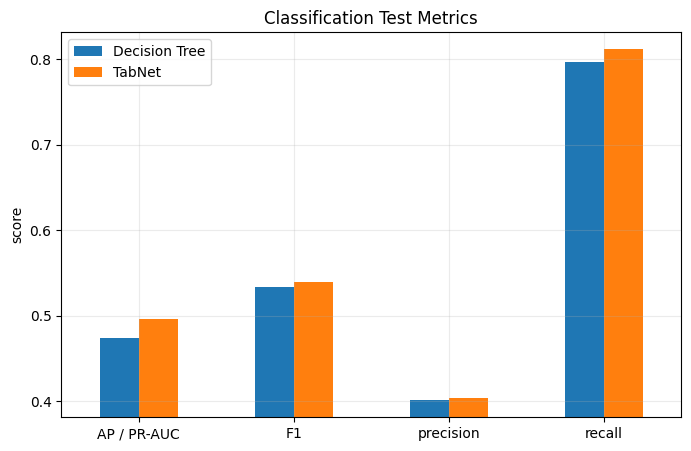

In [123]:
# store the comparison results in a data frame then use display function to show results
tree_results = metric_row("Decision Tree", y_test, tree_test_prob, tree_threshold)
tabnet_results = metric_row("TabNet", y_test, tabnet_test_prob, tabnet_threshold)
classification_results = pd.DataFrame([tree_results, tabnet_results])
display(classification_results)

##########################
# BELOW IS FOR THE TABLE #
##########################

# initialize the df for the table
classification_table = classification_results.copy()
# rename columns 
classification_table = classification_table.rename(columns={
    "model": "Model",
    "threshold": "Threshold",
    "precision": "Precision",
    "recall": "Recall",
    "predicted injury cases": "Predicted Injury Cases",
    "actual injury cases": "Actual Injury Cases",
    "rows": "Rows",
})

# format columns
numeric_cols = ["Threshold", "AP / PR-AUC", "F1", "Precision", "Recall"]
for column in numeric_cols:
    classification_table[column] = classification_table[column].map(lambda value: f"{value:.4f}")

# initialize the table
fig_table, ax_table = plt.subplots(figsize=(10, 1.8))
ax_table.axis("off")

table = ax_table.table(
    cellText=classification_table.values,
    colLabels=classification_table.columns,
    cellLoc="center",
    loc="center",
)

# format table
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.4)

ax_table.set_title("Classification Test Metrics", pad=12)

# fig_table.savefig(FIGURE_DIR / "classification_baseline.png", dpi=200, bbox_inches="tight")
plt.close(fig_table)

##########################
# BELOW IS FOR THE CHART #
##########################

metric_columns = ["AP / PR-AUC", "F1", "precision", "recall"]

fig, ax = plt.subplots(figsize=(8, 5))

classification_results.set_index("model")[metric_columns].T.plot(
    kind="bar",
    rot=0,
    ax=ax
)

# flatten metrics into an array
metric_values = classification_results[metric_columns].to_numpy().ravel()

padding = 0.02

y_min = max(0, metric_values.min() - padding)
y_max = min(1, metric_values.max() + padding)

ax.set_ylim(y_min, y_max)
ax.set_ylabel("score")
ax.set_title("Classification Test Metrics")
ax.legend()
ax.grid(True, alpha=0.25)

# fig.savefig("figures/classification_comparison.png", dpi=200)
plt.show()

## Clustering

### Helper Functions

In [124]:
NUMERIC_CLUSTER_FEATURES = [
    "Train Speed",
    "Estimated Vehicle Speed",
    "Number Vehicle Occupants",
    "Number of Cars",
    "Temperature",
]

ALL_CATEGORICAL_CLUSTER_FEATURES = [
    "season",
    "time_of_day",
    "Highway User",
    "Highway User Position",
    "Equipment Involved",
    "Equipment Struck",
    "Equipment Type",
    "Track Type",
    "Warning Connected To Signal",
    "Crossing Illuminated",
    "Visibility",
    "Weather Condition",
    "View Obstruction",
    "Highway User Action",
    "Driver Passed Vehicle",
    "Driver In Vehicle",
]

CATEGORICAL_CLUSTER_FEATURES = [
    feature for feature in ALL_CATEGORICAL_CLUSTER_FEATURES
    if feature != "time_of_day"
]

BINARY_CLUSTER_FEATURES = [
    "has_gate",
    "has_cantilever_fls",
    "has_standard_fls",
    "has_wig_wags",
    "has_highway_traffic_signals",
    "has_audible",
    "has_crossbucks",
    "has_stop_signs",
    "has_watchman",
    "has_flagged_by_crew",
    "has_other_warning",
    "has_no_warning_device",
]

CLUSTER_FEATURES = NUMERIC_CLUSTER_FEATURES + CATEGORICAL_CLUSTER_FEATURES + BINARY_CLUSTER_FEATURES

def prepare_cluster_data(df) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    This function separates and returns the profiling features and the features we will use for the modeling. Convert numeric features and fill missing values with the median; Fill missing values for categorical features to "Missing"; Likewise convert binary features to numeric and fill missing values.
    """

    model_df = df[CLUSTER_FEATURES].copy()
    profile_df = df[["Report Key", "year", "fatality_present", "injury_present", "time_of_day"]].copy()

    for column in NUMERIC_CLUSTER_FEATURES:
        model_df[column] = pd.to_numeric(model_df[column], errors="coerce")
        model_df[column] = model_df[column].fillna(model_df[column].median())

    for column in CATEGORICAL_CLUSTER_FEATURES:
        model_df[column] = model_df[column].fillna("Missing").astype(str)

    for column in BINARY_CLUSTER_FEATURES:
        model_df[column] = pd.to_numeric(model_df[column], errors="coerce").astype(int)

    profile_df["time_of_day"] = profile_df["time_of_day"].astype("string").fillna("Missing").astype(str)
    return model_df, profile_df

def compute_gower_style_distance(model_sample, numeric_reference_df) -> np.ndarray:
    """
    This function ultimatley returns the distance matrix that will be used for clustering. We inititialize two empty 2000x2000 matrices that will contain the total accumulated difference between two rows, and the weighted sum which simply counted the # of valid feature comparisons. For numeric features, we convert to numpy array for size 2000x1, compare row to row values and add them into the distance matrix, finally dividing by the feature range for scaling. For categorical, if the features are the same, add 0, different add 1, each categorical feature contributes equally to the total distance matrix. For binary we create both a relevant and different matrix, if the data points are both different and relevant we add one to the distance matrix, we also add the relevant matrix to the weighted sum. 
    """

    n_rows = len(model_sample)
    distance_sum = np.zeros((n_rows, n_rows), dtype=np.float32)
    weight_sum = np.zeros((n_rows, n_rows), dtype=np.float32)

    for column in NUMERIC_CLUSTER_FEATURES:
        values = model_sample[column].to_numpy(dtype=np.float32)
        feature_range = numeric_reference_df[column].max() - numeric_reference_df[column].min()
        if feature_range == 0:
            continue
        distance_sum += np.abs(values[:, None] - values[None, :]) / feature_range
        weight_sum += 1

    for column in CATEGORICAL_CLUSTER_FEATURES:
        values = model_sample[column].astype(str).to_numpy()
        distance_sum += (values[:, None] != values[None, :]).astype(np.float32)
        weight_sum += 1

    for column in BINARY_CLUSTER_FEATURES:
        values = model_sample[column].to_numpy(dtype=np.int8)
        relevant = (values[:, None] == 1) | (values[None, :] == 1)
        different = values[:, None] != values[None, :]
        distance_sum += (different & relevant).astype(np.float32)
        weight_sum += relevant.astype(np.float32)

    distance_matrix = np.divide(distance_sum, weight_sum, out=np.zeros_like(distance_sum), where=weight_sum != 0)
    np.fill_diagonal(distance_matrix, 0.0)
    return distance_matrix

def run_pam(distance_matrix, k) -> tuple[np.ndarray, np.ndarray, float]:
    """
    This function runs the PAM/k-medoids clustering algorithm using the a distance matrix and k value. It returns cluster labels, the selected medoids, and the final cluster loss as a float.
    """

    result = kmedoids.pam(
        diss=distance_matrix,
        medoids=k,
        random_state=CLUSTER_SEED,
    )
    return result.labels, float(result.loss)

def summarize_clusters(model_sample, profile_sample, labels) -> tuple[pd.Series, pd.DataFrame, pd.DataFrame]:
    """
    This function takes in the sample data, profile data, and the labels for those data points. It returns a series of the labels counts, a df of the numeric columns where the rows represent the clusters and the values per row are the median, and another df of fatality_present and injury_present columns where each row is a percentage per cluster of those columns.
    """

    clustered = model_sample.copy()
    clustered["cluster"] = labels
    profiled = profile_sample.copy()
    profiled["cluster"] = labels

    sizes = pd.Series(labels).value_counts().sort_index()
    numeric = clustered.groupby("cluster")[NUMERIC_CLUSTER_FEATURES].median()
    outcomes = profiled.groupby("cluster")[["fatality_present", "injury_present"]].mean().mul(100)
    return sizes, numeric, outcomes

### Shared Sample and Distance Matrix

In [125]:
# separate into what can be clustered and what is simply used as interpretation
cluster_model_df, cluster_profile_df = prepare_cluster_data(v1_df)

# 2000 samples
sample_indices = cluster_model_df.sample(n=2000, random_state=CLUSTER_SEED).index
# index the 2000 samples
model_sample = cluster_model_df.loc[sample_indices].reset_index(drop=True)
profile_sample = cluster_profile_df.loc[sample_indices].reset_index(drop=True)

# calculate the shared distance matrix
distance_matrix = compute_gower_style_distance(model_sample, cluster_model_df)

### K-medoids / PAM

In [126]:
# variable to store looping results
pam_rows = []
pam_results = {}

# loop through different k values, for each run the experiment and capture the results
for k in range(2, 9):
    labels, total_cost = run_pam(distance_matrix, k)
    silhouette = silhouette_score(distance_matrix, labels, metric="precomputed")
    sizes = pd.Series(labels).value_counts()
    # store the results
    pam_rows.append({
        "k": k,
        "silhouette": silhouette,
        "total_cost": total_cost,
        "smallest_cluster": int(sizes.min()),
        "largest_cluster": int(sizes.max()),
    })
    # store the labels for each k
    pam_results[k] = labels

# convert to df, sort the dataframe and obtain the k value for the best score
pam_evaluation = pd.DataFrame(pam_rows)
selected_k = int(pam_evaluation.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])
pam_labels = pam_results[selected_k]

display(pam_evaluation.round(4))

,k,silhouette,total_cost,smallest_cluster,largest_cluster
0,2,0.1454,541.7935,577,1423
1,3,0.1331,511.1334,421,1128
2,4,0.1025,490.4126,354,821
3,5,0.0935,475.7438,310,622
4,6,0.0980,461.2048,184,594
5,7,0.0726,450.6052,174,401
6,8,0.0746,440.4261,157,360


### HDBSCAN

In [127]:
###############################################
# FIRST TEST ALL THE PARAMETERS AND PICK BEST #
###############################################

# collect evaluation results for each parameter
hdbscan_rows = []
# store the actual cluster labels for each tested setting for retrieval after finding the best
hdbscan_labels_by_params = {}

# loop through cluster_selection_method
for method in ["eom", "leaf"]:
    # loop through min_cluster_size
    for min_cluster_size in [5, 10, 15, 20, 25, 30, 50]:
        # loop through min_samples
        for min_samples in [None, 1, 3, 5, 10, 20]:
            # initialize the model
            model = HDBSCAN(
                metric="precomputed",
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
                cluster_selection_method=method,
                n_jobs=-1,
                copy=True,
            )
            # numpy array where -1 is classified as noise
            labels = model.fit_predict(distance_matrix)
            # masking that will show where there are true clusters
            clustered_mask = labels != -1
            # apply the mask so we can extract the "True" values
            clustered_labels = labels[clustered_mask]
            # sizes will be a series where the indexes are the cluster labels and the values are the counts
            sizes = pd.Series(clustered_labels).value_counts()
            cluster_count = len(sizes)
            noise_percent = (labels == -1).mean() * 100
            clustered_count = int(clustered_mask.sum())
            silhouette = np.nan

            # calculate silhouette score only if possible
            if cluster_count >= 2 and clustered_count > cluster_count:
                silhouette = silhouette_score(
                    # filter the distance matrix
                    distance_matrix[np.ix_(clustered_mask, clustered_mask)],
                    clustered_labels,
                    metric="precomputed",
                )

            # add all the information for display and comparision
            hdbscan_rows.append({
                "method": method,
                "min_cluster_size": min_cluster_size,
                "min_samples": min_samples,
                "cluster_count": cluster_count,
                "noise_percent": noise_percent,
                "clustered_count": clustered_count,
                "smallest_cluster": 0 if sizes.empty else int(sizes.min()),
                "largest_cluster": 0 if sizes.empty else int(sizes.max()),
                "clustered_silhouette": silhouette,
            })
            # tuple[parameters]: labels -> dict key/value pair
            hdbscan_labels_by_params[(method, min_cluster_size, min_samples)] = labels

hdbscan_evaluation = pd.DataFrame(hdbscan_rows)
# filter the hdbscan results
valid_hdbscan = hdbscan_evaluation[
    (hdbscan_evaluation["cluster_count"] >= 2)
    & (hdbscan_evaluation["noise_percent"] <= 90)
    & (hdbscan_evaluation["smallest_cluster"] >= 20)
    & hdbscan_evaluation["clustered_silhouette"].notna()
]

# from the filtered list, sort by silhouette and keep the best one
selected_hdbscan = valid_hdbscan.sort_values(
    ["clustered_silhouette", "noise_percent", "cluster_count"],
    ascending=[False, True, False],
).iloc[0]

# grab the tuple from the that representst the
hdbscan_key = (
    selected_hdbscan["method"],
    int(selected_hdbscan["min_cluster_size"]),
    None if pd.isna(selected_hdbscan["min_samples"]) else int(selected_hdbscan["min_samples"]),
)
# grab label ndarray
hdbscan_labels = hdbscan_labels_by_params[hdbscan_key]

display(selected_hdbscan.to_frame("selected").T)

,method,min_cluster_size,min_samples,cluster_count,noise_percent,clustered_count,smallest_cluster,largest_cluster,clustered_silhouette
selected,eom,10,5.0,2,87.45,251,24,227,0.383187


#### Interpretation

In [129]:
# HDBSCAN post-hoc cluster interpretation.
# hdbscan_labels is aligned row-for-row with model_sample and profile_sample.

hdbscan_profile_model = model_sample.copy()
hdbscan_profile_info = profile_sample.copy()

hdbscan_profile_model["cluster"] = hdbscan_labels
hdbscan_profile_info["cluster"] = hdbscan_labels

hdbscan_profile_model["cluster_label"] = hdbscan_profile_model["cluster"].map(
    lambda label: "noise" if label == -1 else f"cluster_{int(label)}"
)
hdbscan_profile_info["cluster_label"] = hdbscan_profile_info["cluster"].map(
    lambda label: "noise" if label == -1 else f"cluster_{int(label)}"
)

# Focus the interpretation on actual HDBSCAN clusters, not noise.
hdbscan_clustered_model = hdbscan_profile_model[hdbscan_profile_model["cluster"] != -1].copy()
hdbscan_clustered_info = hdbscan_profile_info[hdbscan_profile_info["cluster"] != -1].copy()

hdbscan_cluster_order = sorted(
    hdbscan_clustered_model["cluster_label"].unique(),
    key=lambda label: int(label.split("_")[1]),
)

hdbscan_size_profile = (
    hdbscan_clustered_model["cluster_label"]
    .value_counts()
    .reindex(hdbscan_cluster_order)
    .rename("rows")
    .to_frame()
)

hdbscan_size_profile["percent_of_sample"] = (
    hdbscan_size_profile["rows"] / len(hdbscan_profile_model) * 100
).round(2)

hdbscan_numeric_profile = (
    hdbscan_clustered_model
    .groupby("cluster_label")[NUMERIC_CLUSTER_FEATURES]
    .median()
    .reindex(hdbscan_cluster_order)
    .round(2)
)

hdbscan_outcome_profile = (
    hdbscan_clustered_info
    .groupby("cluster_label")[["fatality_present", "injury_present"]]
    .mean()
    .mul(100)
    .reindex(hdbscan_cluster_order)
    .round(2)
)

# Add time_of_day back for interpretation even though it was not used for fitted clustering.
hdbscan_categorical_source = hdbscan_profile_model.copy()
hdbscan_categorical_source["time_of_day"] = hdbscan_profile_info["time_of_day"].values

hdbscan_categorical_features = CATEGORICAL_CLUSTER_FEATURES + ["time_of_day"]
hdbscan_categorical_rows = []

for feature in hdbscan_categorical_features:
    overall_rates = hdbscan_categorical_source[feature].value_counts(normalize=True, dropna=False)

    for cluster_label, group in hdbscan_categorical_source[hdbscan_categorical_source["cluster"] != -1].groupby("cluster_label"):
        cluster_rates = group[feature].value_counts(normalize=True, dropna=False)
        cluster_counts = group[feature].value_counts(dropna=False)

        for value, cluster_rate in cluster_rates.items():
            overall_rate = overall_rates.get(value, 0)

            hdbscan_categorical_rows.append({
                "cluster_label": cluster_label,
                "feature": feature,
                "value": value,
                "cluster_count": int(cluster_counts[value]),
                "cluster_percent": cluster_rate * 100,
                "overall_percent": overall_rate * 100,
                "difference_points": (cluster_rate - overall_rate) * 100,
            })

hdbscan_top_categorical = (
    pd.DataFrame(hdbscan_categorical_rows)
    .sort_values(["cluster_label", "difference_points"], ascending=[True, False])
    .groupby("cluster_label")
    .head(5)
    .round(2)
)

hdbscan_warning_rows = []
overall_warning_rates = hdbscan_profile_model[BINARY_CLUSTER_FEATURES].mean()

for cluster_label, group in hdbscan_clustered_model.groupby("cluster_label"):
    cluster_warning_rates = group[BINARY_CLUSTER_FEATURES].mean()

    for feature, cluster_rate in cluster_warning_rates.items():
        overall_rate = overall_warning_rates[feature]

        hdbscan_warning_rows.append({
            "cluster_label": cluster_label,
            "warning_feature": feature,
            "cluster_percent": cluster_rate * 100,
            "overall_percent": overall_rate * 100,
            "difference_points": (cluster_rate - overall_rate) * 100,
        })

hdbscan_top_warning_rates = (
    pd.DataFrame(hdbscan_warning_rows)
    .sort_values(["cluster_label", "difference_points"], ascending=[True, False])
    .groupby("cluster_label")
    .head(5)
    .round(2)
)

display(hdbscan_size_profile)
display(hdbscan_numeric_profile)
display(hdbscan_outcome_profile)
display(hdbscan_top_categorical)
display(hdbscan_top_warning_rates)

,rows,percent_of_sample
cluster_label,,
cluster_0,227,11.35
cluster_1,24,1.20


,Train Speed,Estimated Vehicle Speed,Number Vehicle Occupants,Number of Cars,Temperature
cluster_label,,,,,
cluster_0,29.0,8.0,1.0,46.0,70.0
cluster_1,40.0,0.0,0.0,72.5,53.0


,fatality_present,injury_present
cluster_label,,
cluster_0,10.57,39.21
cluster_1,0.00,0.00


,cluster_label,feature,value,cluster_count,cluster_percent,overall_percent,difference_points
35,cluster_0,Crossing Illuminated,No,202,88.99,56.65,32.34
40,cluster_0,Visibility,Day,191,84.14,57.40,26.74
24,cluster_0,Equipment Type,Freight Train,217,95.59,70.95,24.64
56,cluster_0,Highway User Action,Did not stop,173,76.21,51.60,24.61
30,cluster_0,Warning Connected To Signal,No,213,93.83,69.70,24.13
18,cluster_1,Highway User Position,Stalled or stuck on crossing,24,100.00,10.25,89.75
65,cluster_1,Driver In Vehicle,No,24,100.00,13.30,86.70
60,cluster_1,Highway User Action,Stopped on crossing,24,100.00,27.05,72.95
44,cluster_1,Visibility,Dark,19,79.17,35.10,44.07
39,cluster_1,Crossing Illuminated,No,24,100.00,56.65,43.35


,cluster_label,warning_feature,cluster_percent,overall_percent,difference_points
6,cluster_0,has_crossbucks,94.71,64.05,30.66
11,cluster_0,has_no_warning_device,0.00,0.00,0.00
8,cluster_0,has_watchman,0.00,0.30,-0.30
3,cluster_0,has_wig_wags,0.44,1.65,-1.21
4,cluster_0,has_highway_traffic_signals,0.00,2.65,-2.65
18,cluster_1,has_crossbucks,87.50,64.05,23.45
23,cluster_1,has_no_warning_device,0.00,0.00,0.00
20,cluster_1,has_watchman,0.00,0.30,-0.30
15,cluster_1,has_wig_wags,0.00,1.65,-1.65
16,cluster_1,has_highway_traffic_signals,0.00,2.65,-2.65


### Classification Results & Plot

,method,sample rows,clusters,noise percent,clustered rows,main score,score note
0,K-medoids / PAM,2000,2,0.00,2000,0.1454,silhouette on all points
1,HDBSCAN,2000,2,87.45,251,0.3832,silhouette on non-noise points


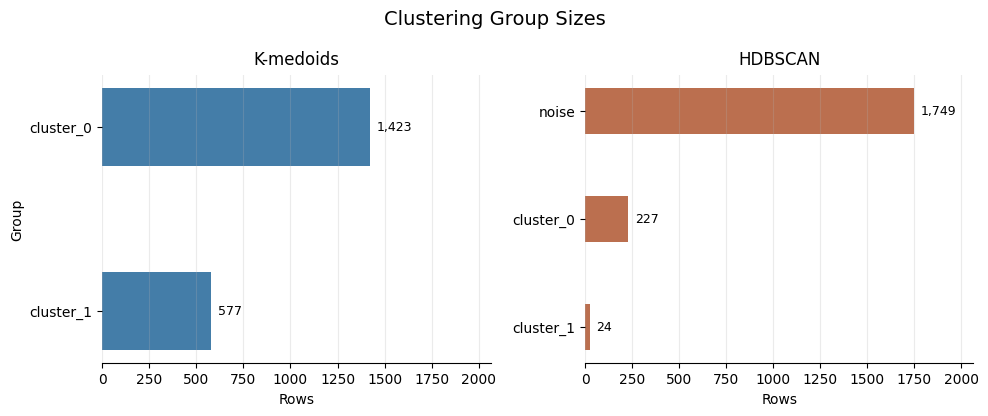

In [130]:
# dataframe for the comparison
clustering_comparison = pd.DataFrame([
    {
        "method": "K-medoids / PAM",
        "sample rows": len(model_sample),
        "clusters": selected_k,
        "noise percent": 0.0,
        "clustered rows": len(model_sample),
        "main score": float(pam_evaluation.loc[pam_evaluation["k"] == selected_k, "silhouette"].iloc[0]),
        "score note": "silhouette on all points",
    },
    {
        "method": "HDBSCAN",
        "sample rows": len(model_sample),
        "clusters": int(selected_hdbscan["cluster_count"]),
        "noise percent": float(selected_hdbscan["noise_percent"]),
        "clustered rows": int(selected_hdbscan["clustered_count"]),
        "main score": float(selected_hdbscan["clustered_silhouette"]),
        "score note": "silhouette on non-noise points",
    },
])
# display the comparison
display(clustering_comparison.round(4))

# separte data for the plot
size_rows = []
for label, rows in pd.Series(pam_labels).value_counts().sort_index().items():
    size_rows.append({"method": "K-medoids", "group": f"cluster_{label}", "rows": int(rows)})

for label, rows in pd.Series(hdbscan_labels).replace(-1, "noise").value_counts().items():
    size_rows.append({"method": "HDBSCAN", "group": str(label), "rows": int(rows)})

cluster_size_df = pd.DataFrame(size_rows)

plot_df = cluster_size_df.copy()
plot_df["group"] = plot_df["group"].replace({
    "0": "cluster_0",
    "1": "cluster_1",
})

method_colors = {
    "K-medoids": "#2f6f9f",
    "HDBSCAN": "#b45f3c",
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharex=True)

max_rows = plot_df["rows"].max()

for ax, method in zip(axes, ["K-medoids", "HDBSCAN"]):
    subset = plot_df[plot_df["method"] == method].copy()

    if method == "HDBSCAN":
        order = ["noise", "cluster_0", "cluster_1"]
        subset["group"] = pd.Categorical(subset["group"], categories=order, ordered=True)
        subset = subset.sort_values("group")
    else:
        subset = subset.sort_values("group")

    bars = ax.barh(
        subset["group"],
        subset["rows"],
        height=0.42,
        color=method_colors[method],
        alpha=0.9,
    )

    ax.bar_label(
        bars,
        labels=[f"{value:,}" for value in subset["rows"]],
        padding=5,
        fontsize=9,
    )

    ax.set_title(method, fontsize=12, pad=8)
    ax.set_xlabel("Rows")
    ax.set_xlim(0, max_rows * 1.18)
    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", visible=False)
    ax.invert_yaxis()

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("Group")
axes[1].set_ylabel("")

fig.suptitle("Clustering Group Sizes", fontsize=14, y=0.98)
fig.tight_layout()
# fig.savefig(FIGURE_DIR / "cluster_groups.png", dpi=200, bbox_inches="tight")
plt.show()